# IS477 - Public health indicators and gun violence victimization across Chicago community areas

- Group Member: Vivian Lin and Yoyo Lin

## Introduction

### Motivation

One of our teammates previously lived in Chicago for several months but has not explored many of its neighborhoods due to concerns about personal safety, which limited her ability to see the city beyond familiar areas. This limited exposure sparked our curiosity about how different community areas experience violence differently. In addition, both of us are interested in leveraging societal and medical statistics to better understand these disparities and to explore broader societal issues related to public health, safety, and community well-being.

Building on this curiosity, our project examines how community-level public health and socioeconomic conditions relate to gun violence outcomes across Chicago community areas. We will integrate a community area dataset of selected public health indicators with victim level records of homicide and nonfatal shooting victimizations. Our goal is to identify patterns and associations supported by the data, while communicating results responsibly. We will avoid causal claims and refrain from language that stigmatizes communities.

### Research Questions

#### Primary
1. Which community level public health and socioeconomic indicators are most strongly associated with higher gun violence victimization burden across Chicago community areas?

#### Secondary
1. What is the homicide victim count by community area for each year?
2. What is the total gun violence victim count by community area for each year?
3. What are the aggregated demographic summaries by community area for each year, reported only at safe aggregation levels?


### Imports and Helper Functions

In [112]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import geodatasets
from shapely.geometry import Point
import seaborn as sns
import scipy.stats as stats
import numpy as np

# Helper functions.
# Convert the column names into same format.
def standardize_name(name):
    if pd.isna(name):
        return name
    return str(name).strip().lower().replace(" ", "_") 

# Convert the data in to uppercase.
def to_uppercase(x):
    if pd.isna(x):
        return x
    return str(x).upper()

### Data Processing

In [32]:
# Load the datasets and check for NaN values.
df_vio = pd.read_csv("Violence_Reduction_-_Victims_of_Homicides_and_Non-Fatal_Shootings_20260302.csv")
df_stat = pd.read_csv("Public_Health_Statistics_-_Selected_public_health_indicators_by_Chicago_community_area_-_Historical_20260302.csv")

# Check if there is any data that doesn't have a value.
df_vio["COMMUNITY_AREA"].isna().sum()
df_stat["Community Area Name"].isna().sum()

# Drop rows where "COMMUNITY_AREA" column has nan vaule.
df_vio = df_vio.dropna(subset=["COMMUNITY_AREA"])

# Step 1: Ensure the column namse and the combine keys are having the same format.
df_vio.columns = [standardize_name(col) for col in df_vio.columns]
df_stat.columns = [standardize_name(col) for col in df_stat.columns]

# Step 2: Ensure the combine keys are having the same format.
# Check the information within the keys.
df_vio["community_area"].unique()
df_stat["community_area_name"].unique()

# Mapping for known mismatches, like O'Hare.
name_mapping = {"OHARE": "O'HARE", "Montclaire": "Montclare"}
df_vio["community_area"] = df_vio["community_area"].replace(name_mapping)
df_stat["community_area_name"] = df_stat["community_area_name"].replace(name_mapping)

df_vio["community_area"] = df_vio["community_area"].apply(to_uppercase)
df_stat["community_area_name"] = df_stat["community_area_name"].apply(to_uppercase)

# Step 3: Create crosswalk from number using df_stat as source of truth.
crosswalk = (df_stat[["community_area", "community_area_name"]].drop_duplicates()
             .set_index("community_area_name")["community_area"].to_dict())

# Step 4: Convert to datetime.
df_vio["date"] = pd.to_datetime(df_vio["date"], format="%m/%d/%Y %I:%M:%S %p")
df_vio["date_only"] = df_vio["date"].dt.date
df_vio["year"] = df_vio["date"].dt.year
#df_vio["time"] = df_vio["date"].dt.time

# Step 5: Combine the two datasets with keys.
df_merged = pd.merge(df_vio, df_stat, left_on="community_area", right_on="community_area_name")

# Step 6: Validate the join.
vio_area = df_vio["community_area"].unique()
stat_area = df_stat["community_area_name"].unique()
merged_area = df_merged["community_area_x"].unique()

# Convert arrays to sets.
vio_set = set(vio_area)
stat_set = set(stat_area)
merged_set = set(merged_area)

# Check differences.
print("In vio_area but not in stat_area:", vio_set - stat_set)
print("In stat_area but not in vio_area:", stat_set - vio_set)

print("In vio_area but not in merged_area:", vio_set - merged_set)
print("In merged_area but not in vio_area:", merged_set - vio_set)

print("In stat_area but not in merged_area:", stat_set - merged_set)
print("In merged_area but not in stat_area:", merged_set - stat_set)

# Step 7: Filter the time period where both datasets overlap (2005 to 2010).
df_merged = df_merged[(df_merged["year"] >= 2005) & (df_merged["year"] <= 2011)]

# Save the merged file if needed.
#df_merged.to_csv("merged.csv")


# Output the results.
#df_vio["community_area"].head(5)
#df_vio["community_area"].value_counts()
#f_vio.shape
#df_vio.dtypes
#df_stat["community_area_name"].head(5)
#df_stat["community_area_name"].value_counts()
#df_stat.dtypes
#df_merged.head(5)
# df_merged.shape


In vio_area but not in stat_area: set()
In stat_area but not in vio_area: set()
In vio_area but not in merged_area: set()
In merged_area but not in vio_area: set()
In stat_area but not in merged_area: set()
In merged_area but not in stat_area: set()


### Analysis and Correspond Plot

#### Overall Crime Incident Changes and Crime Maps from 2005 to 2011

???????

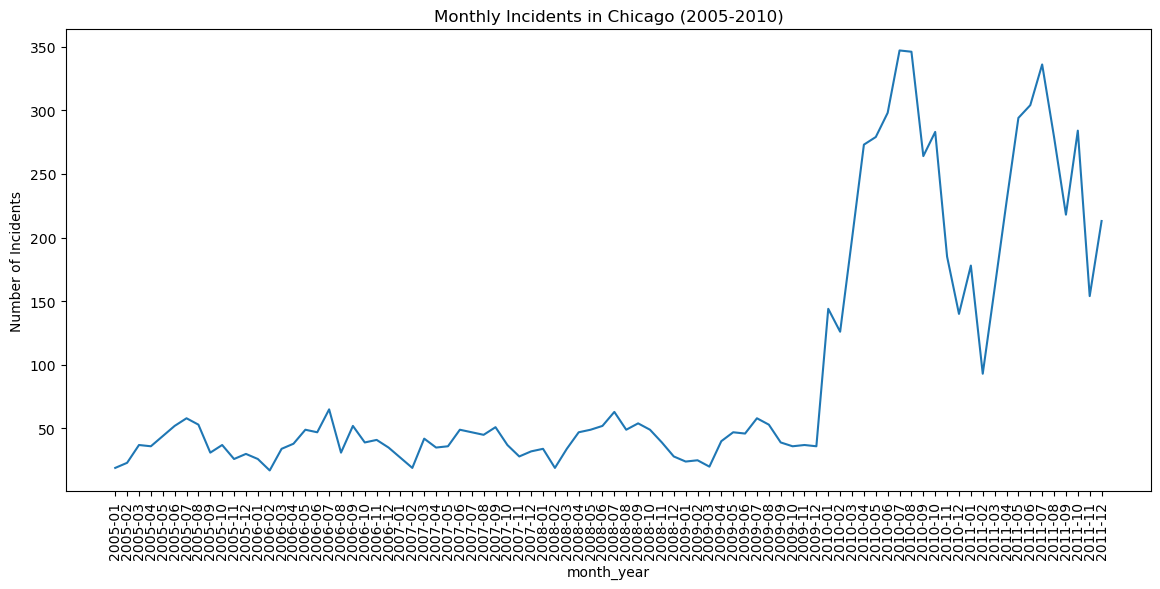

In [142]:
# Overall violence incidents change by year and month.
df_merged["month_year"] = df_merged["date"].dt.to_period("M")

trend_mon = df_merged.groupby("month_year").size().reset_index(name="incidents")
trend_mon["month_year"] = trend_mon["month_year"].astype(str)

# Output the results.
# monthly_trend.head(5)
# monthly_trend.dtypes

# Line plot.
plt.figure(figsize=(14, 6))
sns.lineplot(data=trend_mon, x="month_year", y="incidents")
plt.xticks(rotation=90)
plt.title("Monthly Incidents in Chicago (2005-2010)")
plt.ylabel("Number of Incidents")
plt.show()

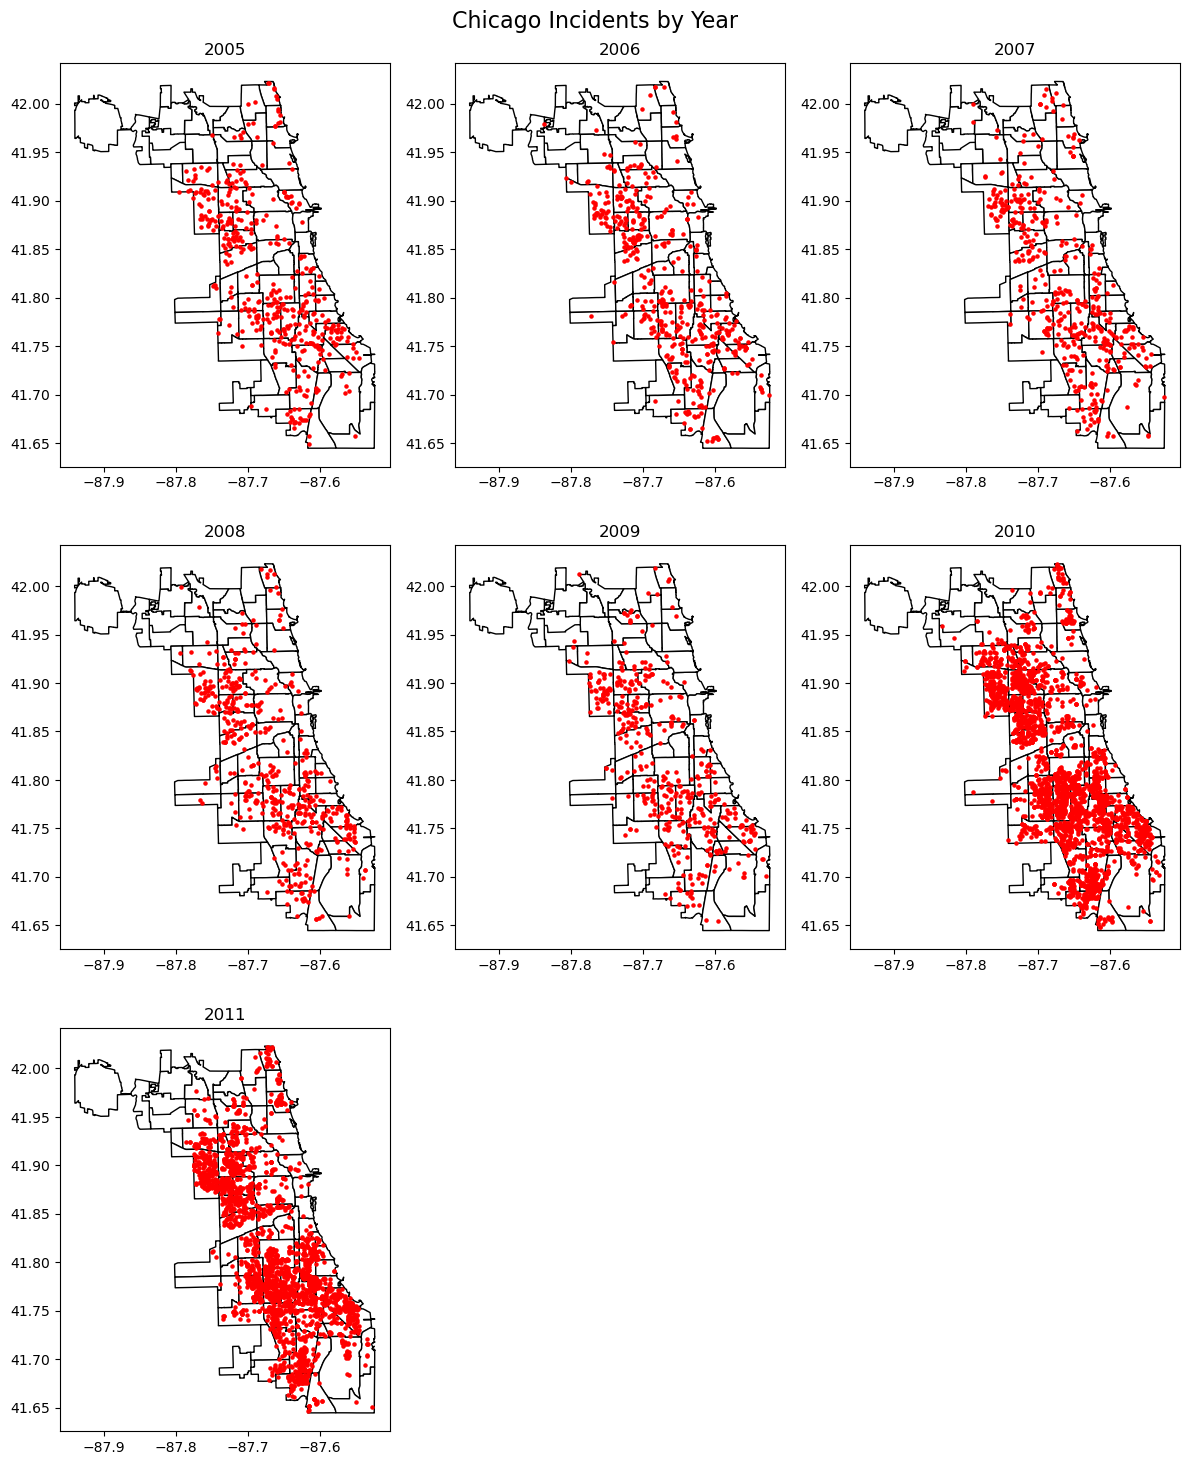

In [143]:
# Method comes from: https://towardsdatascience.com/plotting-maps-with-geopandas-428c97295a73/
# Chicago polygons.
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

# Convert data to a GeoDataFrame.
geometry = [Point(xy) for xy in zip(df_merged["longitude"], df_merged["latitude"])]
geo_df = gpd.GeoDataFrame(df_merged, geometry=geometry)
geo_df.set_crs(epsg=4326, inplace=True)
geo_df = geo_df.to_crs(chicago.crs)

# fig, ax = plt.subplots(figsize=(10, 10))

# # Base map.
# chicago.plot(ax=ax, color="white", edgecolor="black")

# # Data.
# geo_df.plot(ax=ax, color="red", markersize=5)

# plt.title("My Data on Chicago Map")
# plt.show()

# # Assign each point to a community area.
# joined = gpd.sjoin(geo_df, chicago, how="left", predicate='within')

# # Count points per community area.
# counts = joined.groupby("community")[['geometry']].count().rename(columns={'geometry': 'point_count'})

# # Merge counts back to chicago polygons.
# chicago_counts = chicago.merge(counts, left_on="community", right_index=True, how="left")
# chicago_counts['point_count'] = chicago_counts['point_count'].fillna(0)  # fill NaN with 0

# # Plot choropleth.
# fig, ax = plt.subplots(figsize=(10, 10))
# chicago_counts.plot(column='point_count', ax=ax, cmap='OrRd', edgecolor='black', legend=True)
# plt.title("Number of Points per Community Area in Chicago")
# plt.show()

years = sorted(geo_df["year"].dropna().unique())

# Set up the rows and columns for the subplot.
n_cols = 3
n_rows = int(np.ceil(len(years) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    
    # Filter data for that year.
    subset = geo_df[geo_df["year"] == year]
    
    # Base map.
    chicago.plot(ax=ax, color="white", edgecolor="black")
    
    # Points.
    subset.plot(ax=ax, color="red", markersize=5)
    
    ax.set_title(f"{year}")

# Remove empty subplots.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Chicago Incidents by Year", fontsize=16)
plt.tight_layout()
plt.show()

#### Violence Victims Demography

????????

/var/folders/sl/nkyrzpxx0dl5krcsxt3c69cc0000gn/T/ipykernel_81067/2782007847.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_merged, x="age", order=AGES, palette=colors)


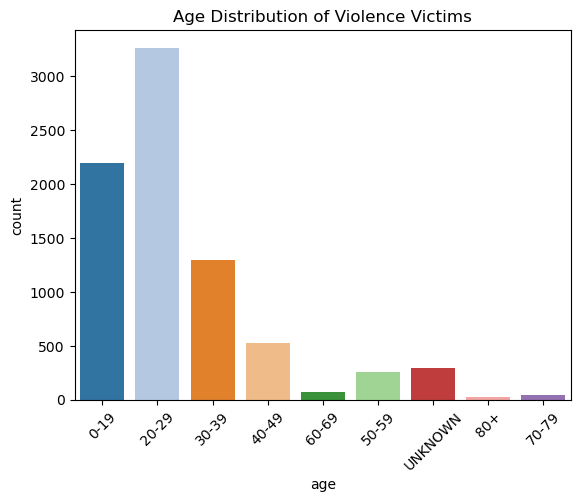

In [ ]:
# Age group distribution.
AGES = df_merged["age"].unique()

# Define a list of colors.
colors = sns.color_palette("tab20", len(AGES)) 

# Bar chart.
sns.countplot(data=df_merged, x="age", order=AGES, palette=colors)
plt.title("Age Distribution of Violence Victims")
plt.xticks(rotation=45)
plt.show()

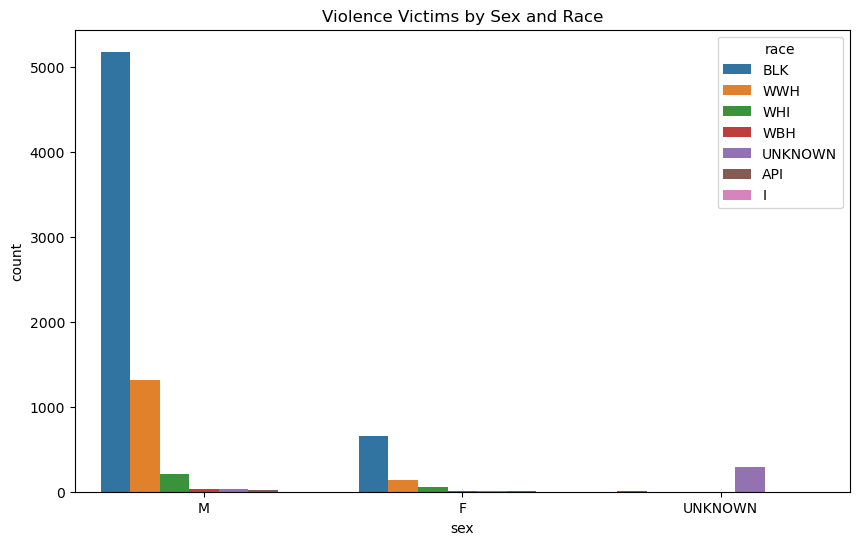

In [144]:
# By sex and race.
plt.figure(figsize=(10, 6))
sns.countplot(data=df_merged, x="sex", hue="race")
plt.title("Violence Victims by Sex and Race")
plt.show()

#### Temporal Patterns for the Violence Incidents

????????????????

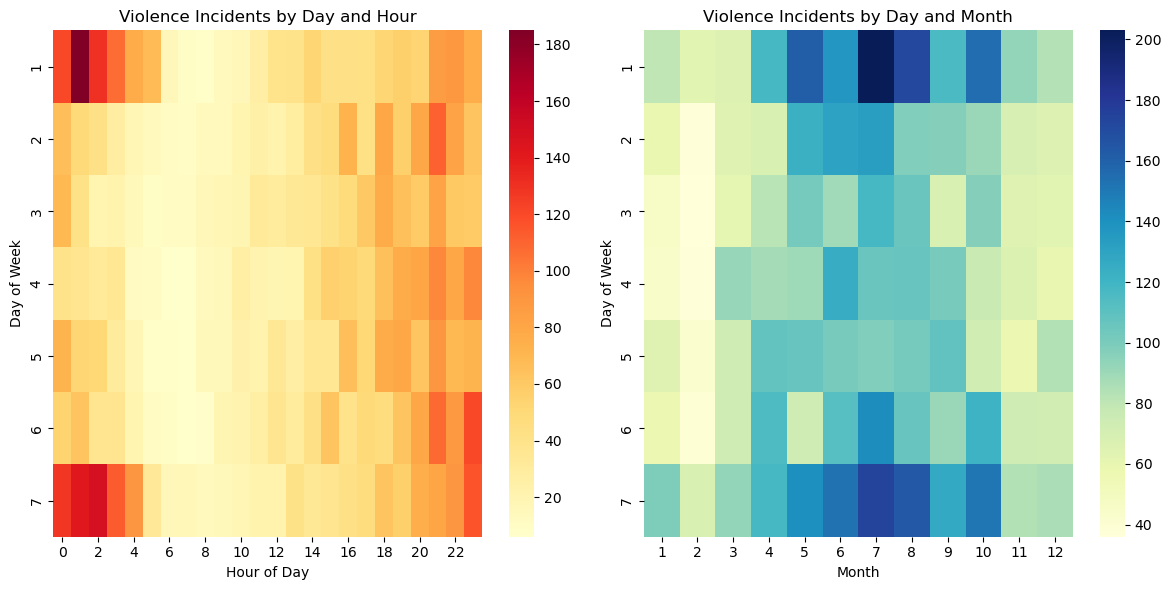

In [ ]:
# Set up the subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Day of week by hour of day.
sns.heatmap(df_merged.pivot_table(index='day_of_week', columns='hour', aggfunc='size', fill_value=0),
            cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Violence Incidents by Day and Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Day of Week')

# Day of week by month.
sns.heatmap(df_merged.pivot_table(index='day_of_week', columns='month', aggfunc='size', fill_value=0),
            cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Violence Incidents by Day and Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

#### Research Questions

##### Q1: Which community level public health and socioeconomic indicators are most strongly associated with higher gun violence victimization burden across Chicago community areas?

##### Q2: What is the homicide victim count by community area for each year?

???????


In [78]:
homicides = df_merged[df_merged["victimization_primary"] == "HOMICIDE"]

homicide_by_area_year = (homicides.groupby(["community_area_name", "year"]).size()
                         .reset_index(name="homicide_victim_count")
                         .sort_values(["community_area_name", "year"]))

# Output the result.
homicide_by_area_year.head(5)

,community_area_name,year,homicide_victim_count
0,ALBANY PARK,2005,4
1,ALBANY PARK,2007,3
2,ALBANY PARK,2008,3
3,ALBANY PARK,2009,8
4,ALBANY PARK,2010,1


In [139]:
# Homicide rate by community area.
homicide_rate = homicides.groupby('community_area_name').size() / df_merged.groupby('community_area_name').size() * 100

homicide_rate.head(10)

community_area_name
ALBANY PARK        52.500000
ARCHER HEIGHTS     76.923077
ARMOUR SQUARE     100.000000
ASHBURN            22.222222
AUBURN GRESHAM     38.187702
AUSTIN             42.307692
AVALON PARK        40.000000
AVONDALE           36.206897
BELMONT CRAGIN     28.688525
BEVERLY            50.000000
dtype: float64

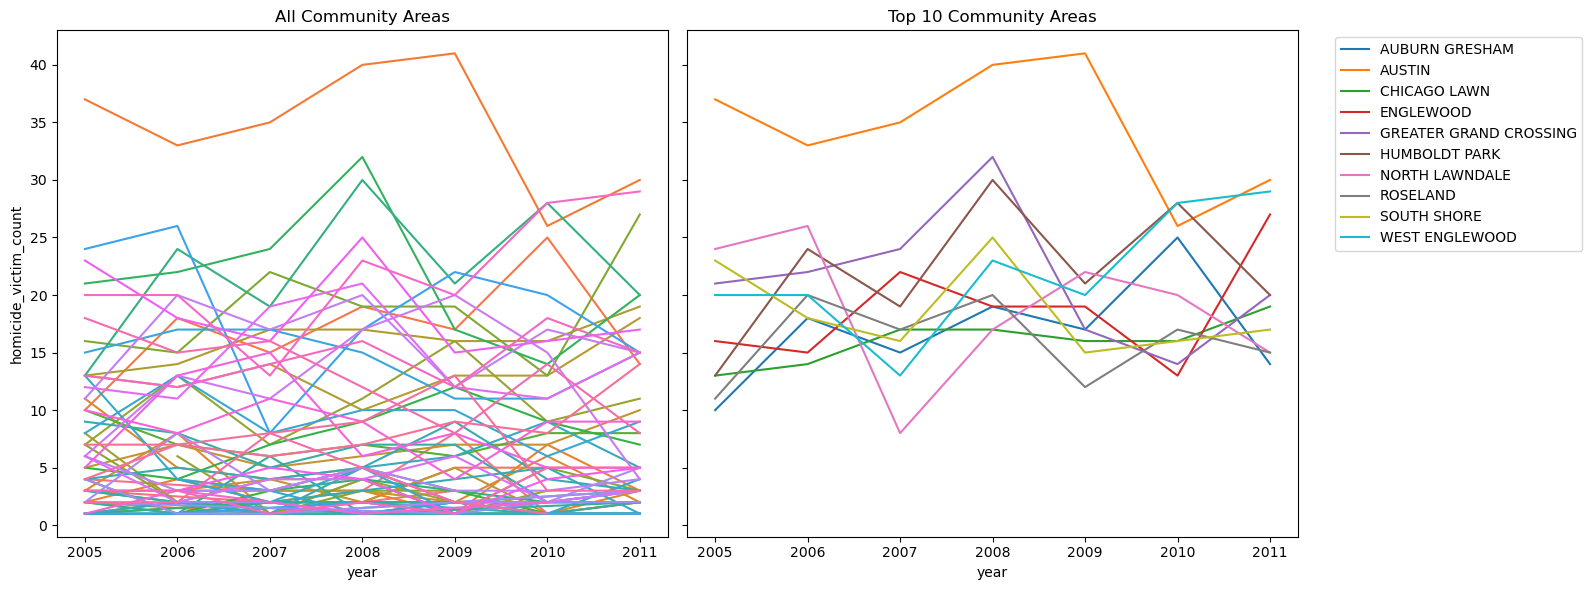

In [158]:
# Find the top 10 areas by total homicides.
top15_areas = (homicide_by_area_year.groupby('community_area_name')['homicide_victim_count']
               .sum().sort_values(ascending=False).head(10).index)

top15_data = homicide_by_area_year[homicide_by_area_year['community_area_name'].isin(top15_areas)]

# Plot the plots side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Line plot for all the community areas.
sns.lineplot(data=homicide_by_area_year, x='year',y='homicide_victim_count', 
             hue='community_area_name', legend=False, ax=axes[0])

axes[0].set_title("All Community Areas")

# Line plot for the community areas that have the top 15 homicides.
sns.lineplot(data=top15_data, x='year', y='homicide_victim_count', 
             hue='community_area_name', ax=axes[1])

axes[1].set_title("Top 10 Community Areas")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

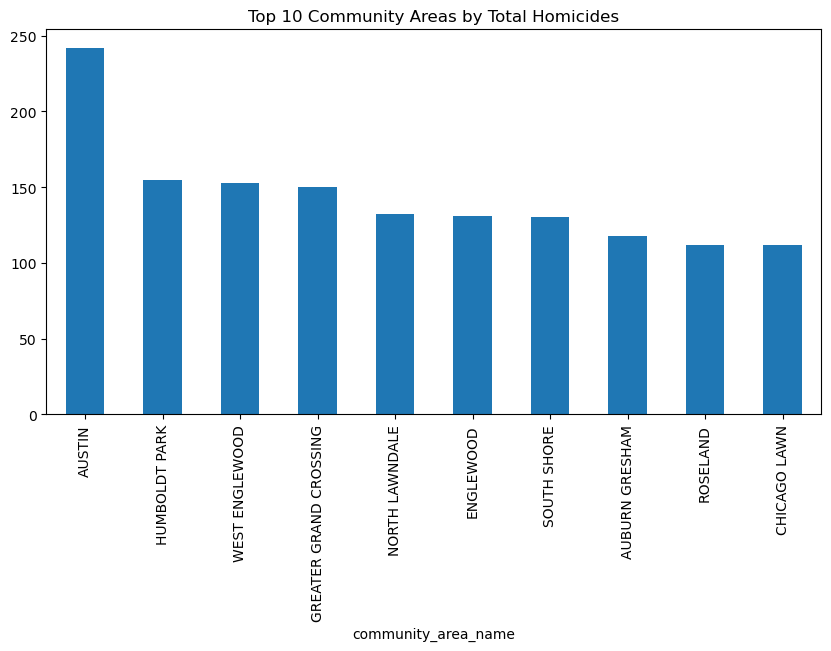

In [159]:
top_areas = (homicide_by_area_year.groupby('community_area_name')['homicide_victim_count']
             .sum().sort_values(ascending=False).head(10))

top_areas.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Community Areas by Total Homicides")
plt.show()

### Q3: What is the homiside and gun injuried victim count by community area for each year?

??????


In [ ]:
# Any non-fatal shooting and under homiside case.
gun_violence = df_merged[(df_merged["victimization_primary"] == "HOMICIDE") & (df_merged['gunshot_injury_i'] == 'YES')]

gun_violence_by_area_year = (gun_violence.groupby(['community_area_name', 'year']).size()
                             .reset_index(name='gun_violence_victims')
                             .sort_values(['community_area_name', 'year']))

gun_violence_by_area_year.head(5)

,community_area_name,year,gun_violence_victims
0,ALBANY PARK,2005,3
1,ALBANY PARK,2007,1
2,ALBANY PARK,2008,3
3,ALBANY PARK,2009,6
4,ALBANY PARK,2010,1


### Q4: What are the aggregated demographic summaries by community area for each year, reported only at safe aggregation levels?

?????

In [ ]:
# Filter to rows that have demographic info
demo = df_merged.dropna(subset=['age', 'sex', 'race']).copy()

# Create age groups.
def age_group(x):
    if pd.isna(x): return 'Unknown'
    if x in ['0-19', '20-29']: return '0-29'
    if x in ['30-39', '40-49']: return '30-49'
    if x in ['50-59', '60-69']: return '50-69'
    return '70+'

demo['age_group'] = demo['age'].apply(age_group)

# Aggregated counts (only at community × year level)
demographic_summary = (demo.groupby(['community_area_name', 'year'])
                       .agg(
                           total_victims=('unique_id', 'nunique'),   # or any ID column
                           male_count=('sex', lambda x: (x=='M').sum()),
                           female_count=('sex', lambda x: (x=='F').sum()),
                           blk_count=('race', lambda x: (x=='BLK').sum()),
                           wwh_count=('race', lambda x: (x=='WWH').sum()),
                           other_race_count=('race', lambda x: (~x.isin(['BLK','WWH'])).sum()),
                           age_0_29=('age_group', lambda x: (x=='0-29').sum()),
                           age_30_49=('age_group', lambda x: (x=='30-49').sum())
                       )
                       .reset_index())

# Optional: add percentages (safe because we're at aggregated level)
for col in ['male_count', 'female_count', 'blk_count', 'wwh_count', 'age_0_29', 'age_30_49']:
    demographic_summary[col.replace('_count', '_pct')] = (
        demographic_summary[col] / demographic_summary['total_victims'] * 100
    ).round(1)

demographic_summary.head(5)

,community_area_name,year,total_victims,male_count,female_count,blk_count,wwh_count,other_race_count,age_0_29,age_30_49,male_pct,female_pct,blk_pct,wwh_pct
0,ALBANY PARK,2005,4,4,0,1,3,0,75.0,25.0,100.0,0.0,25.0,75.0
1,ALBANY PARK,2007,3,2,1,2,1,0,33.3,66.7,66.7,33.3,66.7,33.3
2,ALBANY PARK,2008,3,3,0,0,3,0,66.7,33.3,100.0,0.0,0.0,100.0
3,ALBANY PARK,2009,8,5,3,0,7,1,87.5,12.5,62.5,37.5,0.0,87.5
4,ALBANY PARK,2010,10,7,0,0,4,6,60.0,10.0,70.0,0.0,0.0,40.0


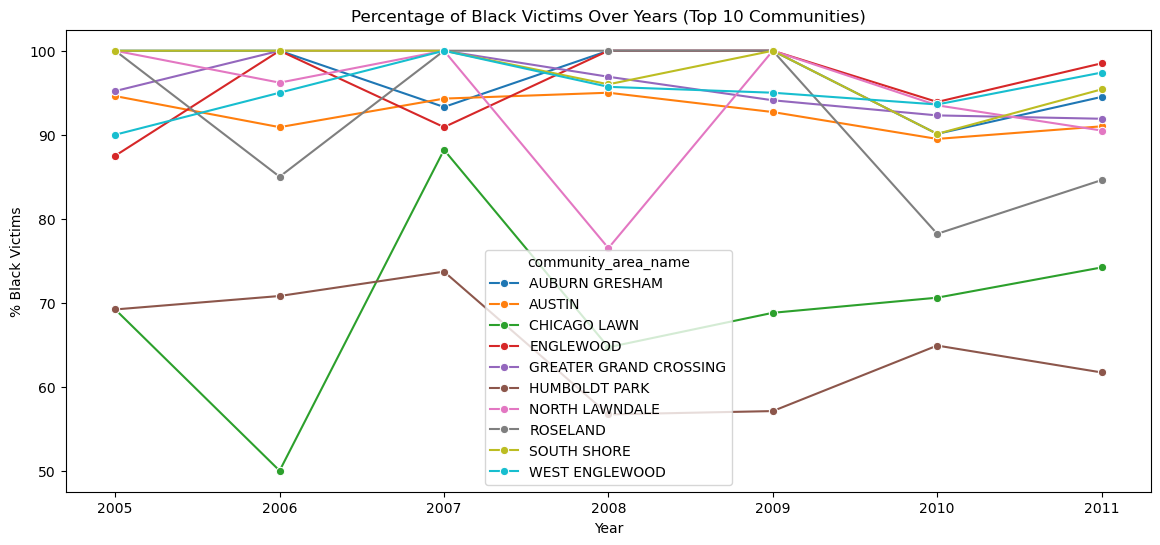

In [167]:
top_areas = demographic_summary.groupby('community_area_name')['total_victims'].sum().nlargest(10).index
subset = demographic_summary[demographic_summary['community_area_name'].isin(top_areas)]

plt.figure(figsize=(14,6))
sns.lineplot(data=subset, x='year', y='blk_pct', hue='community_area_name', marker='o')
plt.title('Percentage of Black Victims Over Years (Top 10 Communities)')
plt.ylabel('% Black Victims')
plt.xlabel('Year')
plt.show()

## Other Visualizations -> 那個correlation plot好像是我們的research question 1?!但我還沒弄上去，因為感覺還能多加一點variables，像什麼死亡率、cancer率之類的

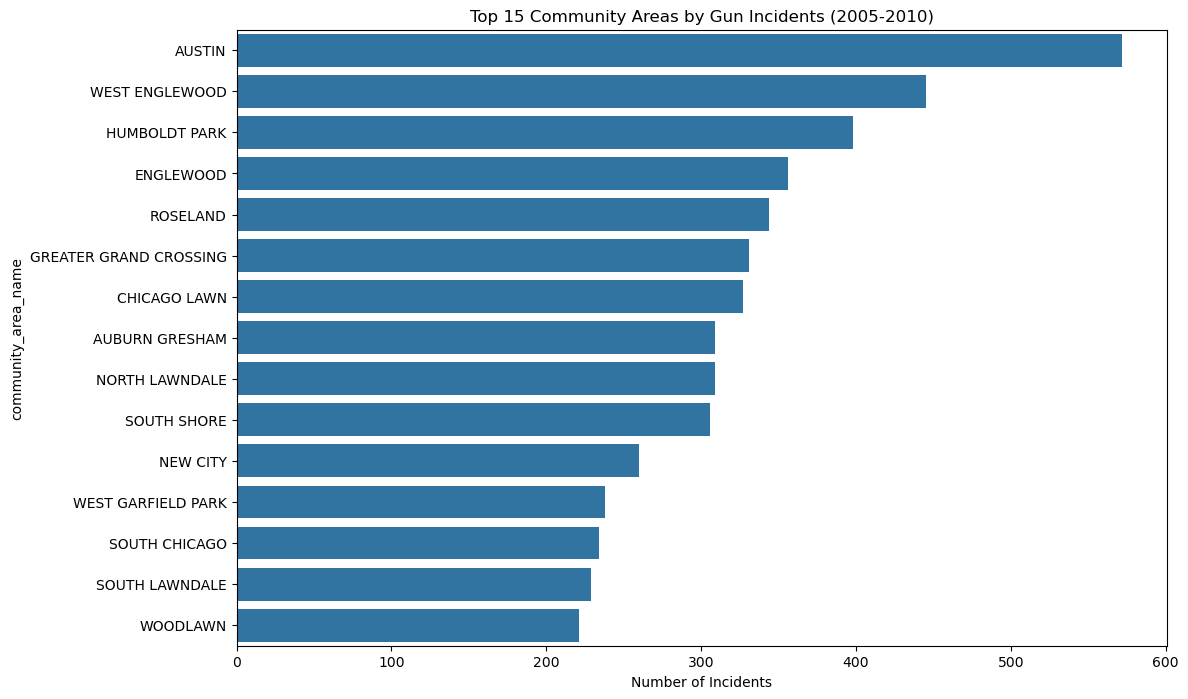

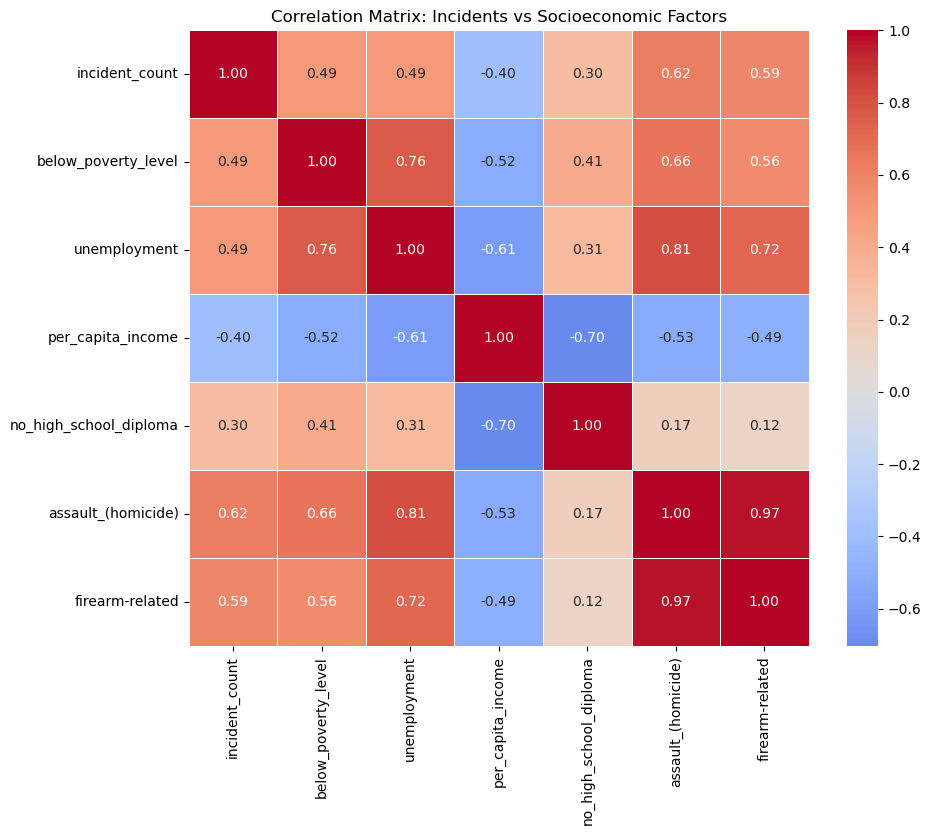

In [89]:
# Full corrected version
area_stats = (df_merged.groupby('community_area_name')
              .agg({
                  'unique_id': 'count',
                  'below_poverty_level': 'mean',
                  'unemployment': 'mean',
                  'per_capita_income': 'mean',
                  'no_high_school_diploma': 'mean',
                  'assault_(homicide)': 'mean',
                  'firearm-related': 'mean'
              })
              .rename(columns={'unique_id': 'incident_count'})
              .reset_index())

socio_cols = ['below_poverty_level', 'unemployment', 'per_capita_income', 
              'no_high_school_diploma', 'assault_(homicide)', 'firearm-related']

# Top 15 most dangerous areas
top15 = area_stats.nlargest(15, 'incident_count')

plt.figure(figsize=(12, 8))
sns.barplot(data=top15, y='community_area_name', x='incident_count')
plt.title('Top 15 Community Areas by Gun Incidents (2005-2010)')
plt.xlabel('Number of Incidents')
plt.show()

# Correlation heatmap
corr = area_stats[['incident_count'] + socio_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Incidents vs Socioeconomic Factors')
plt.show()

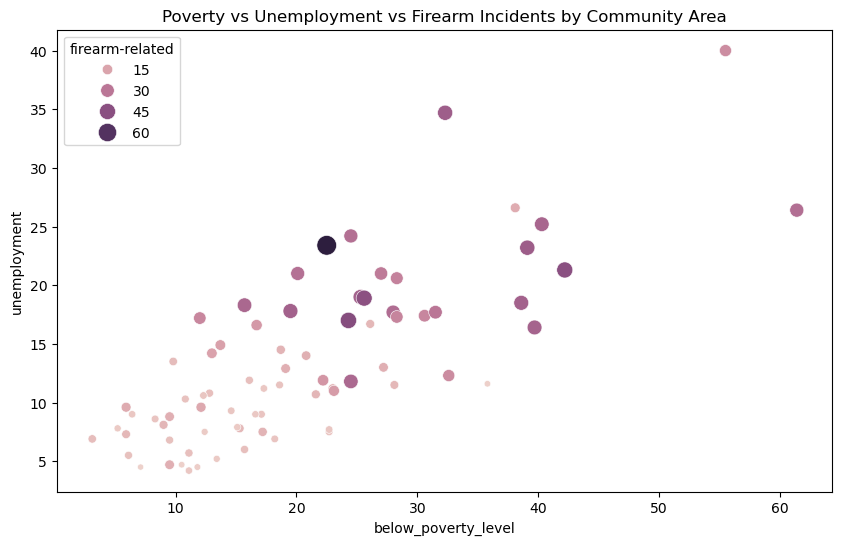

In [43]:
# Relationship between poverty/unemployment and gun violence.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged.groupby('community_area_name').agg({
    'below_poverty_level': 'mean',
    'unemployment': 'mean',
    'firearm-related': 'mean'  # or use incident count
}).reset_index(), 
x='below_poverty_level', y='unemployment', 
size='firearm-related', hue='firearm-related',
sizes=(20, 200))
plt.title('Poverty vs Unemployment vs Firearm Incidents by Community Area')
plt.show()